In [1]:
import pandas as pd

In [2]:
url_gaf = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/gaf_esp.xlsx"

In [3]:
gaf = pd.read_excel(url_gaf)
gaf.head()

,Espécie,Comprimento do Abdômen,Comprimento das Antenas
0,Gafanhoto,0.50,7.0
1,Gafanhoto,0.50,6.0
2,Gafanhoto,0.60,5.5
3,Gafanhoto,0.65,4.5
4,Gafanhoto,0.54,3.2


In [4]:
gaf.describe()

,Comprimento do Abdômen,Comprimento das Antenas
count,100.000000,100.000000
mean,4.936200,5.382400
std,3.343806,2.296001
min,0.500000,0.890000
25%,1.692500,3.775000
50%,4.500000,5.500000
75%,8.200000,7.000000
max,10.000000,9.700000


In [5]:
gaf.groupby("Espécie").describe()

Comprimento do Abdômen                                              \
                           count    mean       std  min    25%    50%    75%   
Espécie                                                                        
Esperança                   50.0  8.1206  1.129729  5.4  7.225  8.200  9.000   
Gafanhoto                   50.0  1.7518  0.786941  0.5  1.200  1.685  2.415   

                Comprimento das Antenas                                       \
            max                   count    mean       std   min    25%   50%   
Espécie                                                                        
Esperança  10.0                    50.0  7.2156  1.334945  4.50  6.205  7.00   
Gafanhoto   3.6                    50.0  3.5492  1.417861  0.89  2.550  3.77   

                     
           75%  max  
Espécie              
Esperança  8.2  9.7  
Gafanhoto  4.3  7.0

<Axes: xlabel='Comprimento do Abdômen', ylabel='Comprimento das Antenas'>

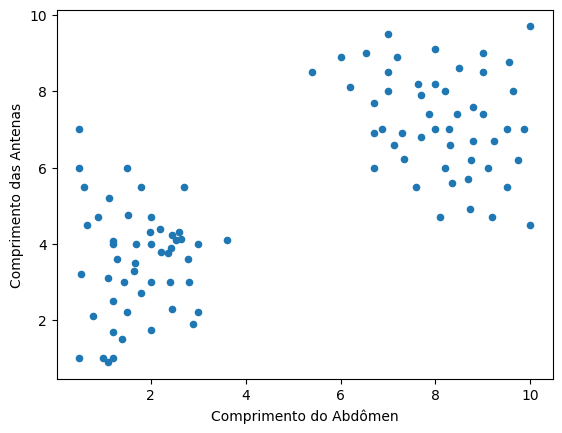

In [6]:
gaf.plot.scatter(x="Comprimento do Abdômen", y="Comprimento das Antenas")

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x=gaf[["Comprimento do Abdômen", "Comprimento das Antenas"]]
y=gaf["Espécie"]

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [10]:
list(y_train).count('Gafanhoto')

40

In [11]:
list(y_train).count('Esperança')

40

In [12]:
print("Total base de treino: ", len(x_train))
print("Total base de teste: ", len(y_test))

Total base de treino:  80
Total base de teste:  20


In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
modelo_classificador = KNeighborsClassifier(n_neighbors=3)
modelo_classificador.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [15]:
modelo_classificador.predict([[8,6]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Esperança'], dtype=object)

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
y_predito = modelo_classificador.predict(x_test)

In [18]:
accuracy_score(y_true = y_test,y_pred = y_predito)

1.0

In [19]:
url_frutas = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/Frutas.xlsx"

In [20]:
frutas = pd.read_excel(url_frutas)
frutas.head()

,Fruta,Calorias
0,Abacaxi,48
1,Amora,43
2,Abacate,160
3,Banana-prata,89
4,Banana-nanica,92


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
lb = LabelEncoder()

In [23]:
frutas["Categoria_Frutas"] = lb.fit_transform(frutas["Fruta"])

In [24]:
frutas.head()

,Fruta,Calorias,Categoria_Frutas
0,Abacaxi,48,1
1,Amora,43,4
2,Abacate,160,0
3,Banana-prata,89,7
4,Banana-nanica,92,6


In [25]:
dum_df = pd.get_dummies(frutas, columns=["Fruta"])

In [26]:
cols_dummies = dum_df.columns.drop("Calorias")
dum_df[cols_dummies] = dum_df[cols_dummies].astype(int)

In [27]:
dum_df

,Calorias,Categoria_Frutas,Fruta_Abacate,Fruta_Abacaxi,Fruta_Acerola,Fruta_Ameixa,Fruta_Amora,Fruta_Banana-maçã,Fruta_Banana-nanica,Fruta_Banana-prata,Fruta_Caju,Fruta_Caqui,Fruta_Carambola,Fruta_Cereja congelada,Fruta_Figo,Fruta_Framboesa
0,48,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,43,4,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,160,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,89,7,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,92,6,0,0,0,0,0,0,1,0,0,0,0,0,0,0
5,89,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0
6,46,11,0,0,0,0,0,0,0,0,0,0,0,1,0,0
7,70,9,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8,31,10,0,0,0,0,0,0,0,0,0,0,1,0,0,0
9,43,8,0,0,0,0,0,0,0,0,1,0,0,0,0,0
